In [43]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
from bgflow import MultiDoubleWellPotential, MeanFreeNormalDistribution
from bgflow.bg import sampling_efficiency
from bgflow.utils import distance_vectors, distances_from_vectors, remove_mean
import matplotlib.pyplot as plt
import numpy as np
import torch

In [45]:
# first define system dimensionality and a target energy/distribution

dim = 8
n_particles = 4
n_dimensions = dim // n_particles

# DW parameters
a=0.9
b=-4
c=0
offset=4

target = MultiDoubleWellPotential(dim, n_particles, a, b, c, offset, two_event_dims=False)

In [46]:
# define a MCMC sampler to sample from the target energy

dw4_data = np.load("/Users/chatan/fast-tbg/data/dw4-dataidx.npy", allow_pickle=True)
all_data = remove_mean(dw4_data[0], n_particles, n_dimensions)
idx = dw4_data[1]
data = all_data[idx[:100000]]
val_data = all_data[idx[100000:500000]]
data_holdout = all_data[idx[-500000:]]

In [47]:
# now load generated samples

DATA_PATH = "/Users/chatan/fast-tbg/logs/eval/runs/2025-01-07_22-12-08/npy_outputs"

samples_proposal = torch.tensor(np.load(DATA_PATH + "/samples_proposal.npy").reshape(-1, dim))
samples_prior = torch.tensor(np.load(DATA_PATH + "/samples_prior.npy").reshape(-1, dim))
log_p_proposal = torch.tensor(np.load(DATA_PATH + "/log_p_proposal.npy"))

In [48]:
importance_weights = torch.exp(- target.energy(samples_proposal).flatten() - log_p_proposal.flatten())

print(importance_weights.shape)

torch.Size([5000])


0.3035416901111603


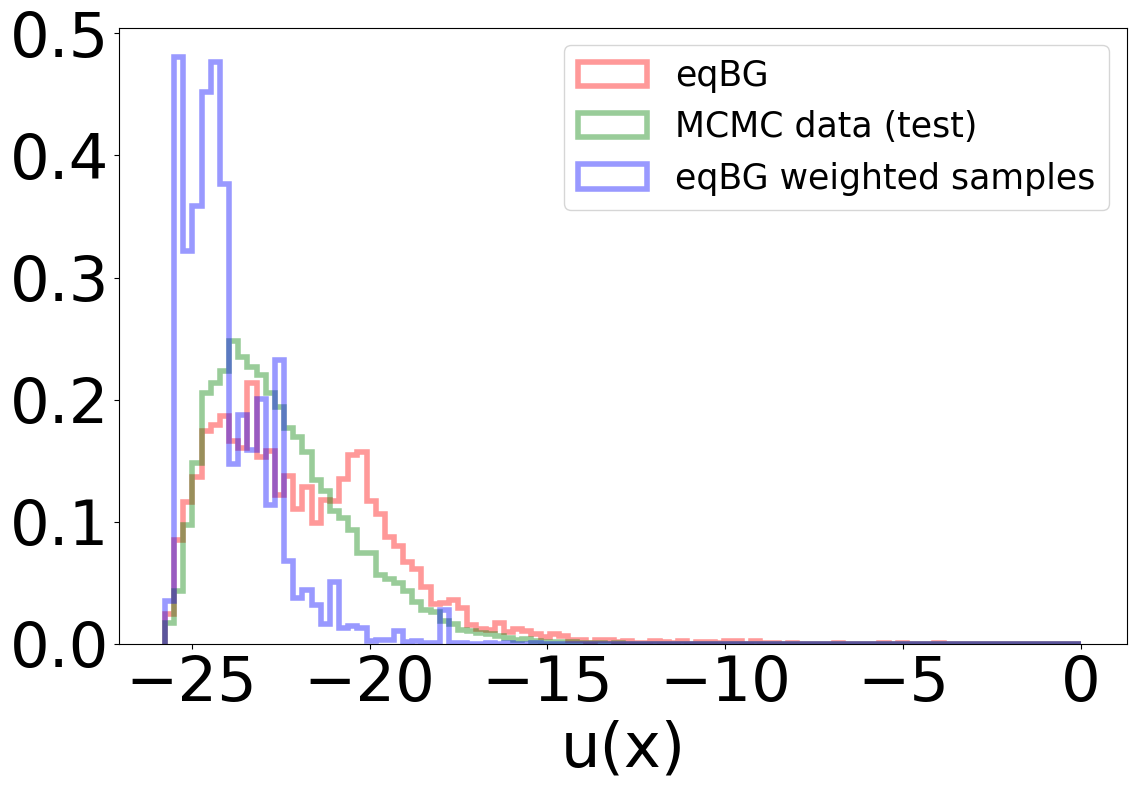

In [49]:
energies_proposal = target.energy(samples_proposal.view(-1, 8)).detach().cpu().numpy()
energies_data = target.energy(data).detach().cpu().numpy()

print(sampling_efficiency(log_p_proposal).item())

energies_prior = target.energy(samples_prior).detach().cpu().numpy()

min_energy = min(energies_data.min(), energies_proposal.min(), energies_prior.min())
max_energy = max(energies_data.max(), energies_proposal.max(), energies_prior.max())

plt.figure(figsize=(13,8))
efac = 1

plt.hist(energies_proposal, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="r", label="eqBG");
plt.hist(energies_data, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="g", histtype='step', linewidth=4, 
         label="MCMC data (test)");
plt.hist(energies_proposal.reshape(-1), bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="b", label="eqBG weighted samples", weights=importance_weights);

plt.xlabel("u(x)", fontsize=45)  
plt.xticks(fontsize=45);
plt.yticks(fontsize=45);
plt.legend( fontsize=25);

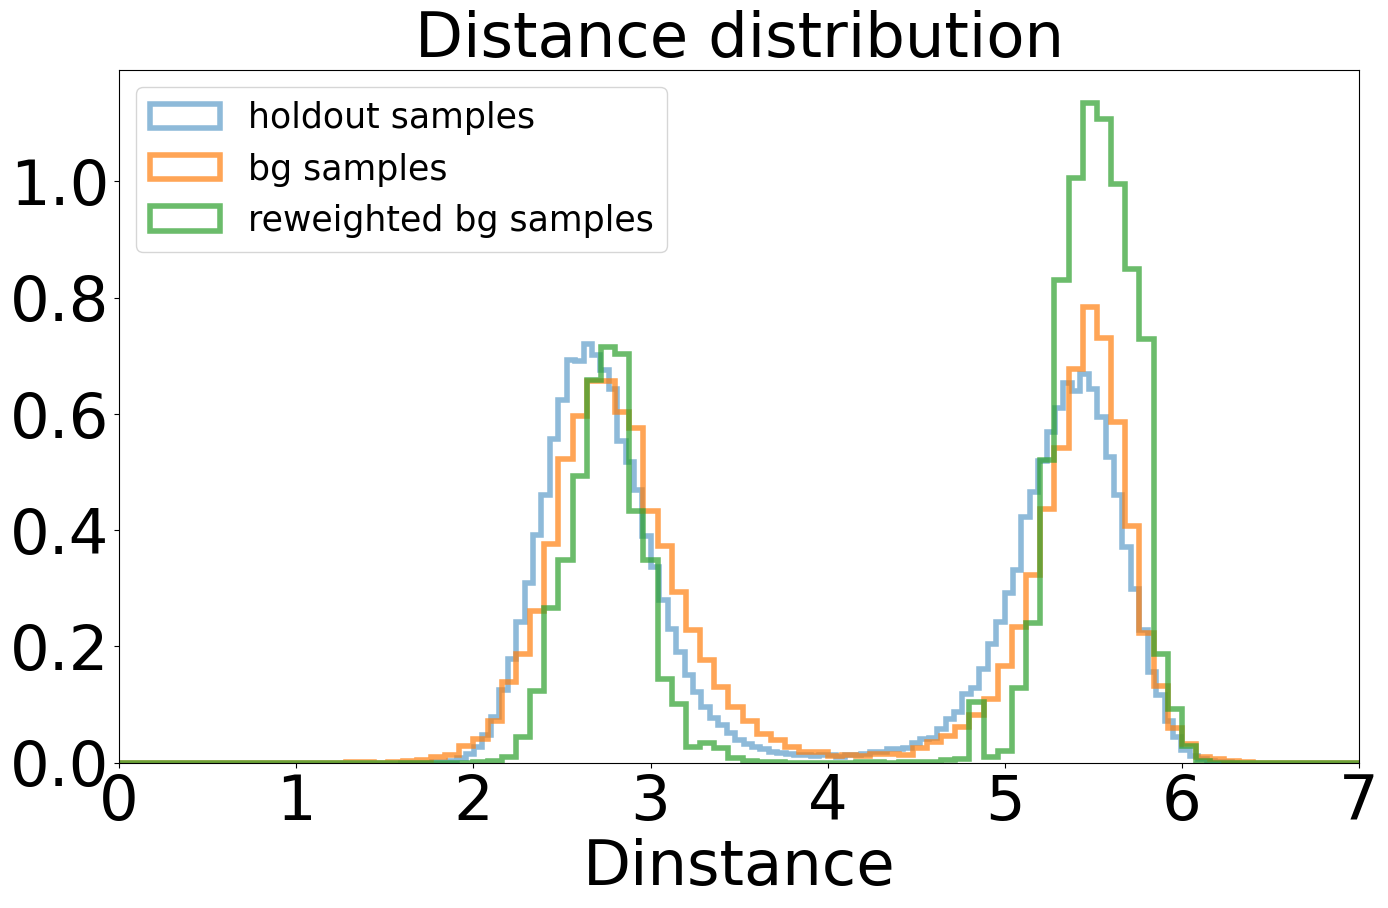

In [50]:
distances = distances_from_vectors(distance_vectors(samples_proposal.view(-1, n_particles, n_dimensions))).reshape(-1)
distances_data = distances_from_vectors(distance_vectors(data_holdout.view(-1, n_particles, dim // n_particles))).reshape(-1)

from bgflow.utils import as_numpy
def distance_energy(d):
    d = d - offset
    return c * d**4 + b * d**2
d = torch.linspace(1, 7, 1000).view(-1, 1) + 1e-6 
u = torch.exp(-(distance_energy(d).view(-1, 1) - offset )).sum(dim=-1, keepdim=True)  * d.abs() **(dim // n_particles - 1)
Z = (u * 1 / (len(d) / (d.max() - d.min()))).sum()
e = u / Z #* 1.1

plt.figure(figsize=(16,9))
# plt.plot(d, e, label="Groundtruth", linewidth=4, alpha = 0.5)
plt.hist(as_numpy(distances_data.view(-1)), bins=100, label="holdout samples", alpha=0.5, density=True, histtype='step', linewidth=4);
plt.hist(distances, bins=100, label="bg samples", alpha=0.7, density=True, histtype='step', linewidth=4, range=(0,8));
plt.hist(distances, bins=100, label="reweighted bg samples", alpha=0.7, density=True, histtype='step',
         linewidth=4, weights=np.repeat(importance_weights.flatten(), n_particles*(n_particles-1)), range=(0,8));
plt.xlim(0,7)
plt.legend(fontsize=25)
plt.xlabel("Dinstance", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.title("Distance distribution", fontsize=45);